1 - Plot the Repos by age group and add the age group next to the main speadsheet

✅ Saved updated CSV with quartile age_group: D:\Android_Mobile_App\AndroidProject_4th\6.2-Shallow_Clone\Analysis Output\7.4-Total_Repos_YML_Merged_Metadata_Updated.csv
✅ Clean Distribution DataFrame (each subgroup sums to 100%):
            Unit Test - Local  Unit Test - CI  Instr Test - Local  \
age_group                                                          
Q1                 23.525557       23.948020           25.103306   
Q2                 24.639581       25.061881           25.103306   
Q3                 26.998689       25.556931           27.169421   
Q4                 24.836173       25.433168           22.623967   

           Instr Test - CI  
age_group                   
Q1               12.735849  
Q2               24.528302  
Q3               29.245283  
Q4               33.490566  

Check sums:
 Unit Test - Local     100.0
Unit Test - CI        100.0
Instr Test - Local    100.0
Instr Test - CI       100.0
dtype: float64


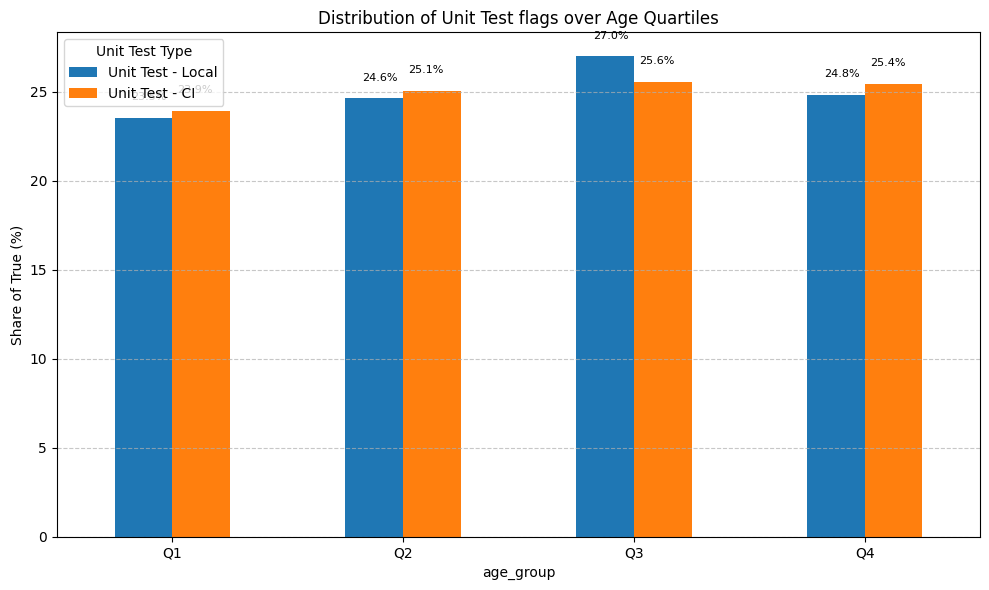

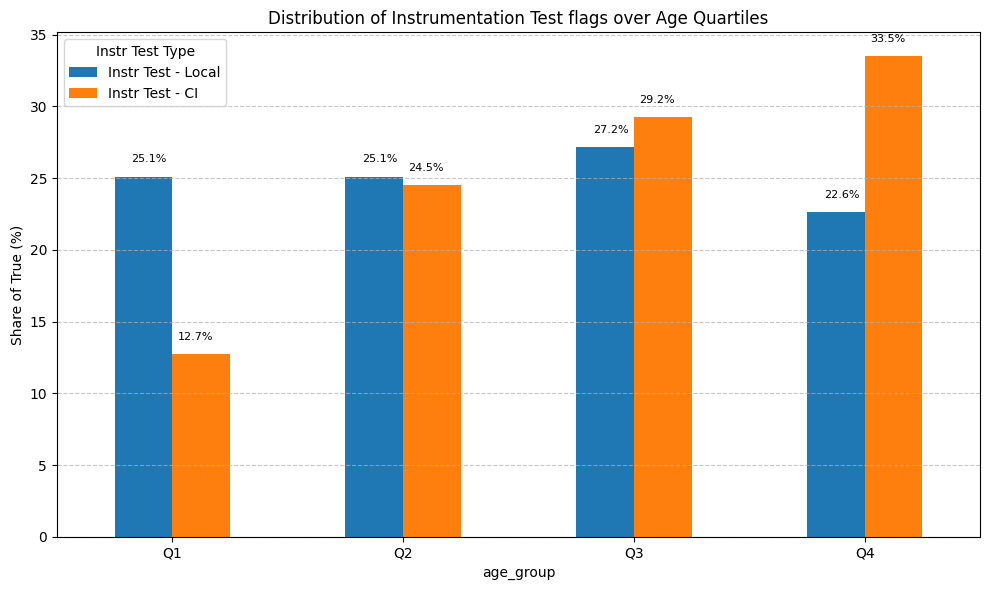

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# === CONFIG ===
file_path = r"D:\Android_Mobile_App\AndroidProject_4th\6.2-Shallow_Clone\Analysis Output\7.4-Total_Repos_YML_Merged_Metadata_Updated.csv"

# === LOAD ===
df = pd.read_csv(file_path)

# === Convert relevant columns to boolean ===
for col in [
    "unit_test_local", "unit_test_ci",
    "instr_test_local", "instr_test_ci",
    "Unit_Test(CI or Local)", "Instr_Test(CI or Local)"
]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.lower() == "true"

# === Compute project age and drop blanks FIRST ===
df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce").dt.tz_localize(None)
df["project_age_years"] = (pd.Timestamp.now() - df["created_at"]).dt.days / 365.25

# Keep only rows with valid project age
df = df.dropna(subset=["project_age_years"])

# === Define quartile age groups ===
df["age_group"] = pd.qcut(df["project_age_years"], q=4, labels=["Q1", "Q2", "Q3", "Q4"])

# === Save updated CSV with age_group at the end ===
cols = [col for col in df.columns if col != "age_group"] + ["age_group"]
df = df[cols]
df.to_csv(file_path, index=False)
print(f"✅ Saved updated CSV with quartile age_group: {file_path}")

# === Compute True distributions per quartile for each subgroup ===
flags = {
    "Unit Test - Local": "unit_test_local",
    "Unit Test - CI": "unit_test_ci",
    "Instr Test - Local": "instr_test_local",
    "Instr Test - CI": "instr_test_ci"
}

distribution = []

for label, col in flags.items():
    # For each flag, only use rows where project_age_years is valid
    flag_df = df[df[col] & df["age_group"].notna()]
    total_true = flag_df.shape[0]
    counts = flag_df.groupby("age_group", observed=True).size()
    percentages = (counts / total_true * 100).reindex(["Q1", "Q2", "Q3", "Q4"]).fillna(0)
    distribution.append(percentages)

distribution_df = pd.DataFrame(distribution, index=flags.keys()).T
print("✅ Clean Distribution DataFrame (each subgroup sums to 100%):\n", distribution_df)
print("\nCheck sums:\n", distribution_df.sum())

# === Split into Unit and Instr DataFrames ===
unit_df = distribution_df[["Unit Test - Local", "Unit Test - CI"]]
instr_df = distribution_df[["Instr Test - Local", "Instr Test - CI"]]

# === Plot Unit Tests ===
ax1 = unit_df.plot(kind="bar", figsize=(10, 6))
ax1.set_ylabel("Share of True (%)")
ax1.set_title("Distribution of Unit Test flags over Age Quartiles")
ax1.set_xticklabels(unit_df.index, rotation=0)
ax1.legend(title="Unit Test Type")
ax1.grid(axis="y", linestyle="--", alpha=0.7)

# Add labels
for i, quartile in enumerate(unit_df.index):
    for j, value in enumerate(unit_df.loc[quartile]):
        ax1.text(i + j * 0.2 - 0.1, value + 1, f"{value:.1f}%", ha="center", fontsize=8)

plt.tight_layout()
plt.show()

# === Plot Instr Tests ===
ax2 = instr_df.plot(kind="bar", figsize=(10, 6))
ax2.set_ylabel("Share of True (%)")
ax2.set_title("Distribution of Instrumentation Test flags over Age Quartiles")
ax2.set_xticklabels(instr_df.index, rotation=0)
ax2.legend(title="Instr Test Type")
ax2.grid(axis="y", linestyle="--", alpha=0.7)

# Add labels
for i, quartile in enumerate(instr_df.index):
    for j, value in enumerate(instr_df.loc[quartile]):
        ax2.text(i + j * 0.2 - 0.1, value + 1, f"{value:.1f}%", ha="center", fontsize=8)

plt.tight_layout()
plt.show()


2 - Plot the Repos by age group and add the age group next to the main speadsheet Only for Isntru Test

✅ Saved updated CSV with quartile age_group: D:\Android_Mobile_App\AndroidProject_4th\6.2-Shallow_Clone\Analysis Output\7.4-Total_Repos_YML_Merged_Metadata_Updated.csv
✅ Rate of True (%) within each quartile:
            Unit Test - Local  Unit Test - CI  Instr Test - Local  \
age_group                                                          
Q1                 56.893819       61.331220           38.510301   
Q2                 59.587956       64.183835           38.510301   
Q3                 65.189873       65.348101           41.613924   
Q4                 60.158730       65.238095           34.761905   

           Instr Test - CI  
age_group                   
Q1                4.278922  
Q2                8.240887  
Q3                9.810127  
Q4               11.269841  


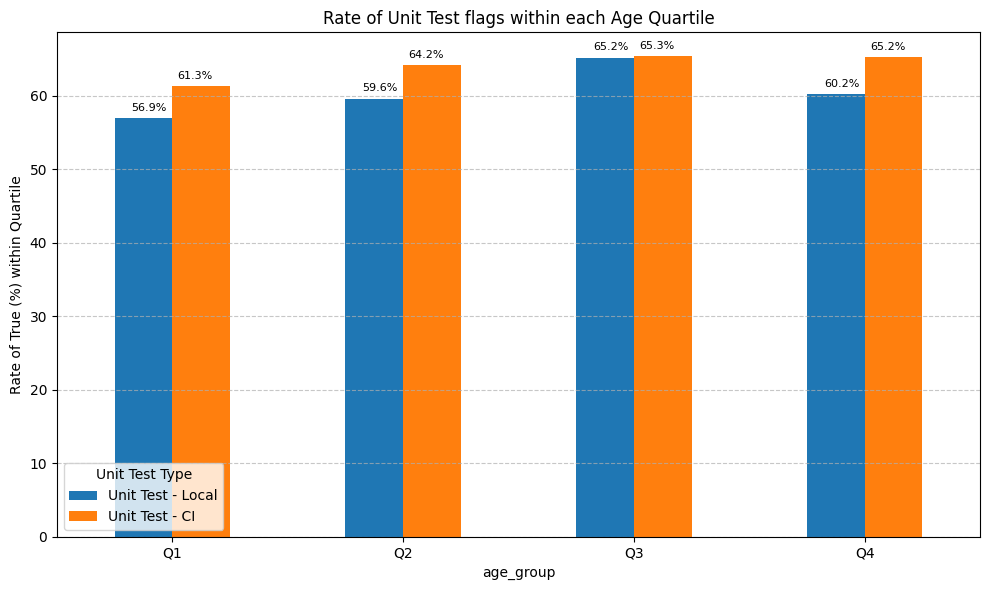

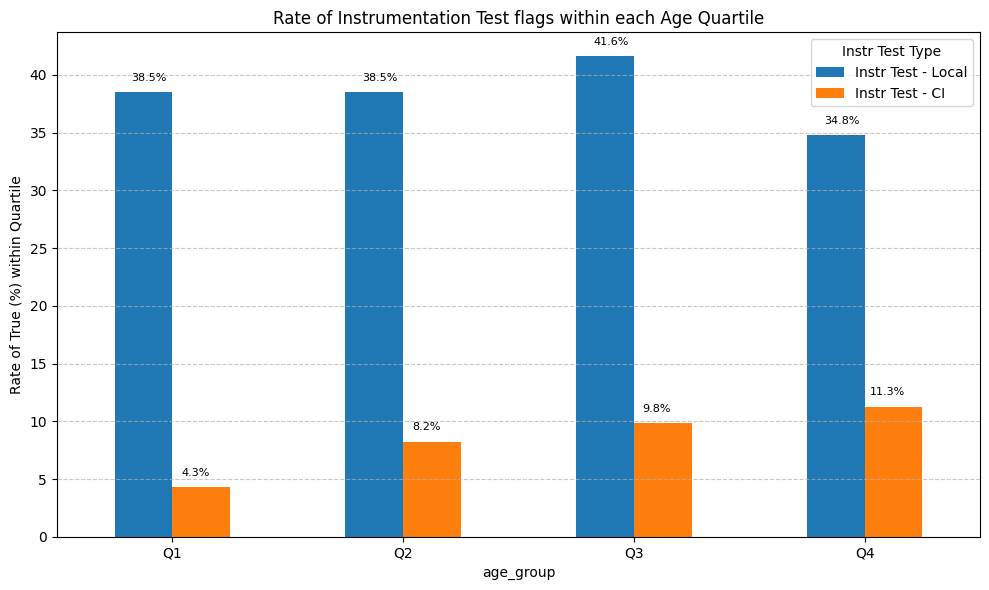

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# === CONFIG ===
file_path = r"D:\Android_Mobile_App\AndroidProject_4th\6.2-Shallow_Clone\Analysis Output\7.4-Total_Repos_YML_Merged_Metadata_Updated.csv"

# === LOAD ===
df = pd.read_csv(file_path)

# === Convert relevant columns to boolean ===
for col in [
    "unit_test_local", "unit_test_ci",
    "instr_test_local", "instr_test_ci",
    "Unit_Test(CI or Local)", "Instr_Test(CI or Local)"
]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.lower() == "true"

# === Compute project age and drop blanks ===
df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce").dt.tz_localize(None)
df["project_age_years"] = (pd.Timestamp.now() - df["created_at"]).dt.days / 365.25

# Keep only rows with valid age
df = df.dropna(subset=["project_age_years"])

# === Define quartiles ===
df["age_group"] = pd.qcut(df["project_age_years"], q=4, labels=["Q1", "Q2", "Q3", "Q4"])

# Save updated CSV with quartile
cols = [col for col in df.columns if col != "age_group"] + ["age_group"]
df = df[cols]
df.to_csv(file_path, index=False)
print(f"✅ Saved updated CSV with quartile age_group: {file_path}")

# === Compute rate of True in each quartile ===
flags = {
    "Unit Test - Local": "unit_test_local",
    "Unit Test - CI": "unit_test_ci",
    "Instr Test - Local": "instr_test_local",
    "Instr Test - CI": "instr_test_ci"
}

rate_data = []

for label, col in flags.items():
    grouped = df.groupby("age_group", observed=True)[col].mean() * 100
    rate_data.append(grouped.reindex(["Q1", "Q2", "Q3", "Q4"]).fillna(0))

rate_df = pd.DataFrame(rate_data, index=flags.keys()).T
print("✅ Rate of True (%) within each quartile:\n", rate_df)

# === Split into Unit & Instr ===
unit_rate_df = rate_df[["Unit Test - Local", "Unit Test - CI"]]
instr_rate_df = rate_df[["Instr Test - Local", "Instr Test - CI"]]

# === Plot Unit Tests ===
ax1 = unit_rate_df.plot(kind="bar", figsize=(10, 6))
ax1.set_ylabel("Rate of True (%) within Quartile")
ax1.set_title("Rate of Unit Test flags within each Age Quartile")
ax1.set_xticklabels(unit_rate_df.index, rotation=0)
ax1.legend(title="Unit Test Type")
ax1.grid(axis="y", linestyle="--", alpha=0.7)

# Add labels
for i, quartile in enumerate(unit_rate_df.index):
    for j, value in enumerate(unit_rate_df.loc[quartile]):
        ax1.text(i + j * 0.2 - 0.1, value + 1, f"{value:.1f}%", ha="center", fontsize=8)

plt.tight_layout()
plt.show()

# === Plot Instr Tests ===
ax2 = instr_rate_df.plot(kind="bar", figsize=(10, 6))
ax2.set_ylabel("Rate of True (%) within Quartile")
ax2.set_title("Rate of Instrumentation Test flags within each Age Quartile")
ax2.set_xticklabels(instr_rate_df.index, rotation=0)
ax2.legend(title="Instr Test Type")
ax2.grid(axis="y", linestyle="--", alpha=0.7)

# Add labels
for i, quartile in enumerate(instr_rate_df.index):
    for j, value in enumerate(instr_rate_df.loc[quartile]):
        ax2.text(i + j * 0.2 - 0.1, value + 1, f"{value:.1f}%", ha="center", fontsize=8)

plt.tight_layout()
plt.show()


Plot the age-group quartiles boxplot

Grouping the repos to these tiers: 

    Tier 1 – CI-Tested Instrumentation
    Tier 2 – Locally-Tested Instrumentation
    Tier 3 – Unite-Tested Only
    Tier 4 – Untested
Saves the Tier of each Repo in the main spreadsheet



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# === CONFIG ===
file_path = r"D:\Android_Mobile_App\AndroidProject_4th\6.2-Shallow_Clone\Analysis Output\7.4-Total_Repos_YML_Merged_Metadata_Updated.csv"

# === LOAD ===
df = pd.read_csv(file_path)

# === Convert relevant columns to boolean ===
for col in [
    "unit_test_local", "unit_test_ci",
    "instr_test_local", "instr_test_ci",
    "Unit_Test(CI or Local)", "Instr_Test(CI or Local)"
]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.lower() == "true"

# === Drop rows with missing critical info (optional: based on created_at or tests) ===
# Here, assume no created_at check needed for Tiers; focus on test flags only.
df = df.dropna(subset=[
    "unit_test_local", "unit_test_ci",
    "instr_test_local", "instr_test_ci"
])

# === Define Tier logic ===
def assign_tier(row):
    if row["instr_test_ci"]:
        return "Tier 1 - CI-Tested Instrumentation"
    elif row["instr_test_local"] and not row["instr_test_ci"]:
        return "Tier 2 - Locally-Tested Instrumentation"
    elif ((row["unit_test_local"] or row["unit_test_ci"]) and not (row["instr_test_local"] or row["instr_test_ci"])):
        return "Tier 3 - Unit Tests Only"
    else:
        return "Tier 4 - Untested"

df["Tier"] = df.apply(assign_tier, axis=1)

# === Reorder columns to place Tier at end ===
cols = [col for col in df.columns if col != "Tier"] + ["Tier"]
df = df[cols]

# === Save updated CSV ===
df.to_csv(file_path, index=False)
print(f"✅ Saved updated CSV with Tier: {file_path}")

# === Compute counts and rates ===
tier_counts = df["Tier"].value_counts().sort_index()
tier_rates = (tier_counts / tier_counts.sum() * 100).round(1)
print("✅ Tier counts:\n", tier_counts)
print("✅ Tier rates (%):\n", tier_rates)

# === Plot ===
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(tier_counts.index, tier_counts.values, color='skyblue')

# Add labels: count + rate
for bar, count, rate in zip(bars, tier_counts.values, tier_rates.values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 2,
            f"{count} ({rate:.1f}%)",
            ha='center', va='bottom', fontsize=9)

ax.set_ylabel("Number of Repositories")
ax.set_title("Repository Count by Tier")
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'D:\\Android_Mobile_App\\AndroidProject_4th\\6.2-Shallow_Clone\\Analysis Output\\7.4-Total_Repos_YML_Merged_Metadata_Updated.csv'

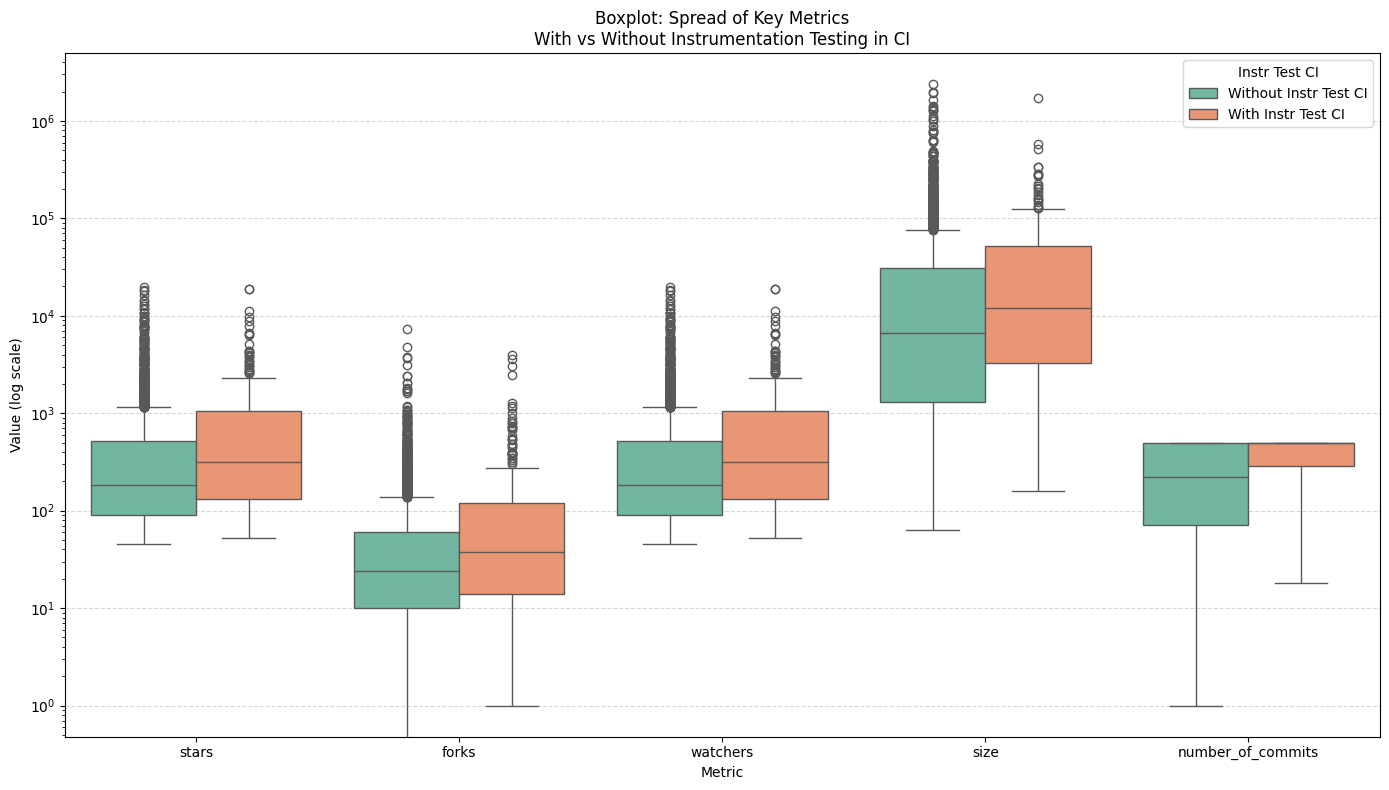

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# === LOAD ===
file_path = r"D:\Android_Mobile_App\AndroidProject_4th\6.2-Shallow_Clone\Analysis Output\7.4-Total_Repos_YML_Merged_Metadata_Updated.csv"
df = pd.read_csv(file_path)

# === Prepare columns ===
df["instr_test_ci"] = df["instr_test_ci"].astype(str).str.lower() == "true"
df["stars"] = pd.to_numeric(df["stars"], errors="coerce")
df["forks"] = pd.to_numeric(df["forks"], errors="coerce")
df["watchers"] = pd.to_numeric(df["watchers"], errors="coerce")
df["size"] = pd.to_numeric(df["size"], errors="coerce")
df["number_of_commits"] = pd.to_numeric(df["number_of_commits"], errors="coerce")

# === Melt for seaborn ===
metrics = ["stars", "forks", "watchers", "size", "number_of_commits"]
df_box = df[["instr_test_ci"] + metrics].copy()
df_box["instr_test_ci"] = df_box["instr_test_ci"].map({True: "With Instr Test CI", False: "Without Instr Test CI"})
df_melted = df_box.melt(id_vars="instr_test_ci", var_name="Metric", value_name="Value")

# === Boxplot ===
plt.figure(figsize=(14, 8))
sns.boxplot(data=df_melted, x="Metric", y="Value", hue="instr_test_ci", palette="Set2")
plt.title("Boxplot: Spread of Key Metrics\nWith vs Without Instrumentation Testing in CI")
plt.ylabel("Value (log scale)")
plt.xlabel("Metric")
plt.yscale("log")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(title="Instr Test CI")
plt.tight_layout()
plt.show()


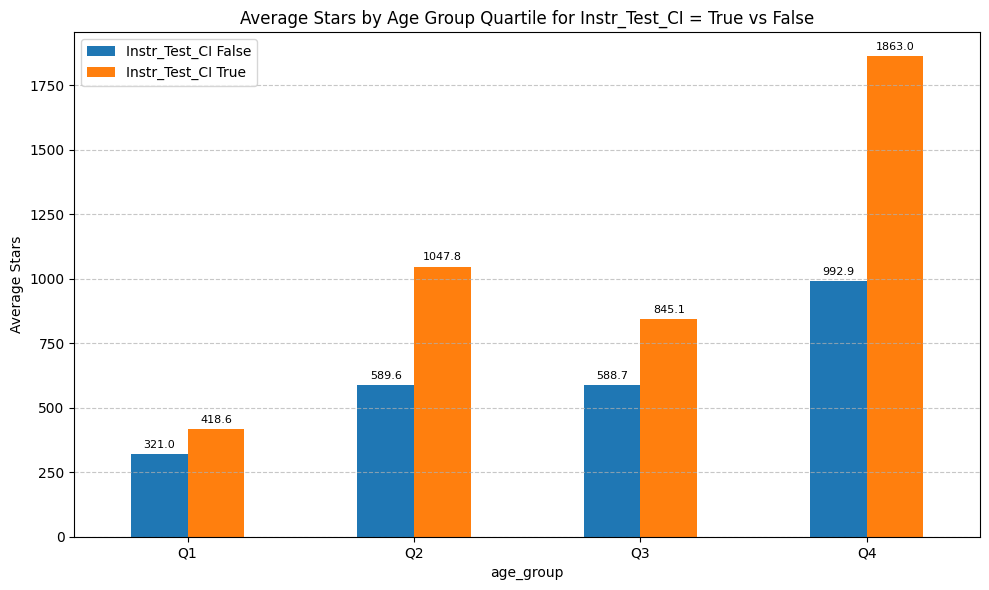

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# === CONFIG ===
file_path = r"D:\Android_Mobile_App\AndroidProject_4th\6.2-Shallow_Clone\Analysis Output\7.4-Total_Repos_YML_Merged_Metadata_Updated.csv"

# === LOAD ===
df = pd.read_csv(file_path)

# === Convert Instr_Test_CI to boolean and stars to numeric ===
df["instr_test_ci"] = df["instr_test_ci"].astype(str).str.lower() == "true"
df["stars"] = pd.to_numeric(df["stars"], errors="coerce")

# === Drop rows with missing age_group or stars ===
df = df.dropna(subset=["age_group", "stars"])

# === Compute mean stars for each age_group & Instr_Test_CI ===
avg_stars = df.groupby(["age_group", "instr_test_ci"])["stars"].mean().unstack(fill_value=0)

# === Rename columns for clarity ===
avg_stars.columns = ["Instr_Test_CI False", "Instr_Test_CI True"]

# === Sort by quartile order ===
avg_stars = avg_stars.reindex(["Q1", "Q2", "Q3", "Q4"])

# === Plot ===
ax = avg_stars.plot(kind="bar", figsize=(10, 6))
ax.set_ylabel("Average Stars")
ax.set_title("Average Stars by Age Group Quartile for Instr_Test_CI = True vs False")
ax.grid(axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=0)

# === Add data labels ===
for i, bar_group in enumerate(ax.containers):
    for bar in bar_group:
        height = bar.get_height()
        ax.annotate(f"{height:.1f}",
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # offset in points
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


Plot the CI Platfomr's with Instrumentation testing Frequency

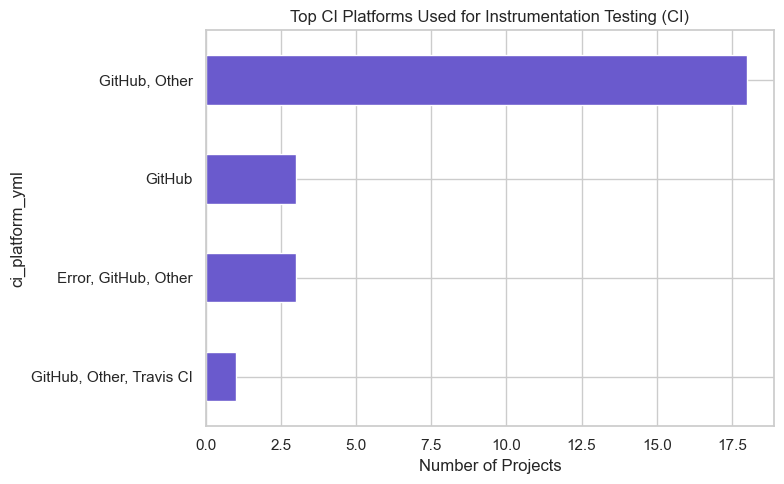

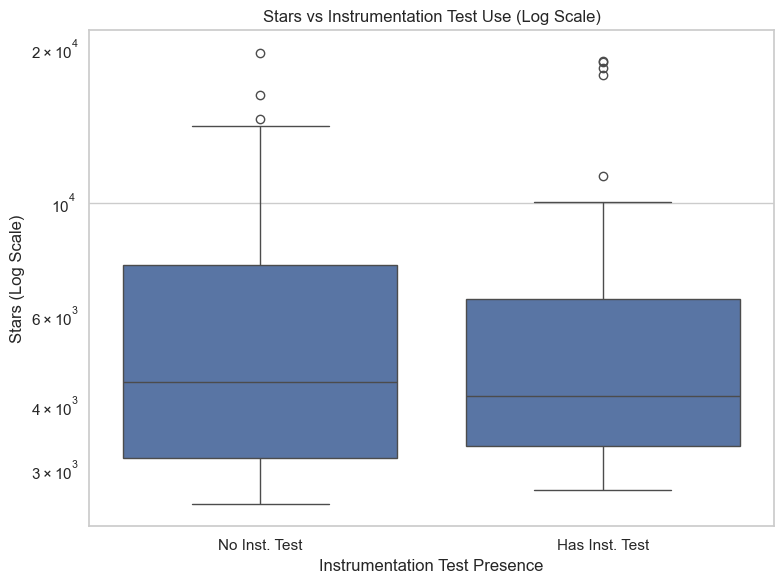

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# === CONFIG ===
file_path = r"D:\Android_Mobile_App\AndroidProject_4th\6.2-Shallow_Clone\Analysis Output\7.4-Total_Repos_YML_Merged_Metadata_Updated.csv"

# === LOAD ===
df = pd.read_csv(file_path)

# === Clean and coerce relevant columns ===
# Ensure Instrumentation test flags are boolean
for col in [
    "instr_test_ci",
    "Instrumentation_Test(Local or CI)"
]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.lower() == "true"

# Clean CI platform column if exists, fallback if missing
ci_col = "CI_Platform_Modified" if "CI_Platform_Modified" in df.columns else "ci_platform_yml"
if ci_col in df.columns:
    df[ci_col] = df[ci_col].fillna("None")
else:
    df[ci_col] = "None"

sns.set(style="whitegrid")

# === 1) Top CI Platforms used for Instrumentation Testing ===
ci_platform_counts = df[df['instr_test_ci'] == True][ci_col].value_counts().head(10)

plt.figure(figsize=(8, 5))
ci_platform_counts.plot(kind='barh', color='slateblue')
plt.title("Top CI Platforms Used for Instrumentation Testing (CI)")
plt.xlabel("Number of Projects")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# === 2) Stars vs. Instrumentation Test Presence (Boxplot, log scale) ===
# Use combined flag if present, fallback to CI+Local
if "Instrumentation_Test(Local or CI)" in df.columns:
    df['Instrumentation_Test(Local or CI)'] = df['Instrumentation_Test(Local or CI)'].astype(str).str.lower() == "true"
    df['Instrumentation Test Presence'] = df['Instrumentation_Test(Local or CI)'].map({True: "Has Inst. Test", False: "No Inst. Test"})
else:
    # Fallback: combine local + CI manually
    df['Instrumentation Test Presence'] = df.apply(lambda row: "Has Inst. Test" if row.get('instr_test_ci', False) or row.get('instr_test_local', False) else "No Inst. Test", axis=1)

# Ensure stars is numeric
df['stars'] = pd.to_numeric(df['stars'], errors='coerce')
df_plot = df[['Instrumentation Test Presence', 'stars']].dropna()

plt.figure(figsize=(8, 6))
sns.boxplot(x='Instrumentation Test Presence', y='stars', data=df_plot)
plt.yscale('log')
plt.title("Stars vs Instrumentation Test Use (Log Scale)")
plt.ylabel("Stars (Log Scale)")
plt.xlabel("Instrumentation Test Presence")
plt.tight_layout()
plt.show()


C:\Users\Admin\AppData\Local\Temp\ipykernel_11588\4087376081.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group_df['api_level'] = group_df['api_level'].astype(int)


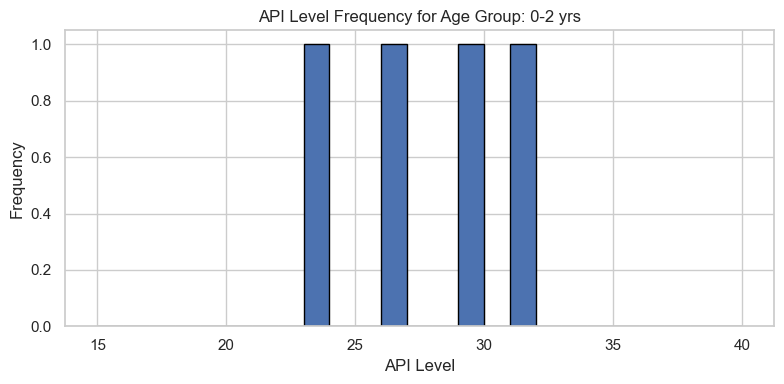

C:\Users\Admin\AppData\Local\Temp\ipykernel_11588\4087376081.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group_df['api_level'] = group_df['api_level'].astype(int)


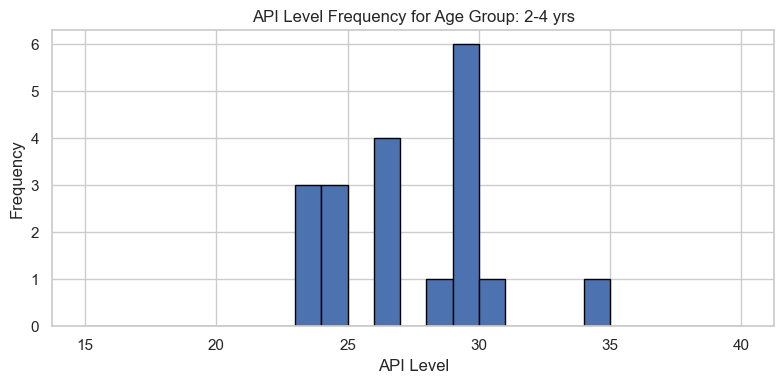

C:\Users\Admin\AppData\Local\Temp\ipykernel_11588\4087376081.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group_df['api_level'] = group_df['api_level'].astype(int)


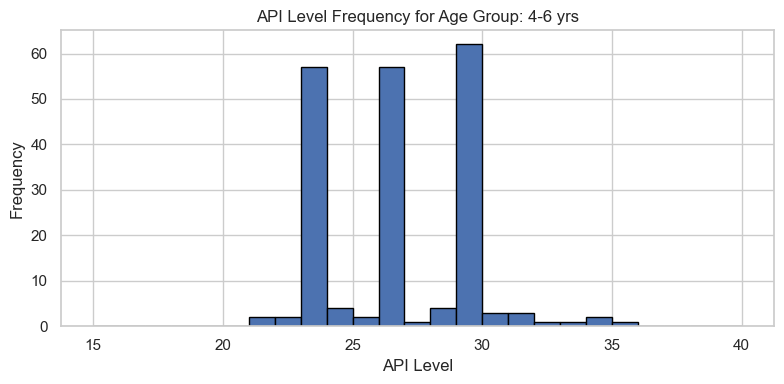

C:\Users\Admin\AppData\Local\Temp\ipykernel_11588\4087376081.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group_df['api_level'] = group_df['api_level'].astype(int)


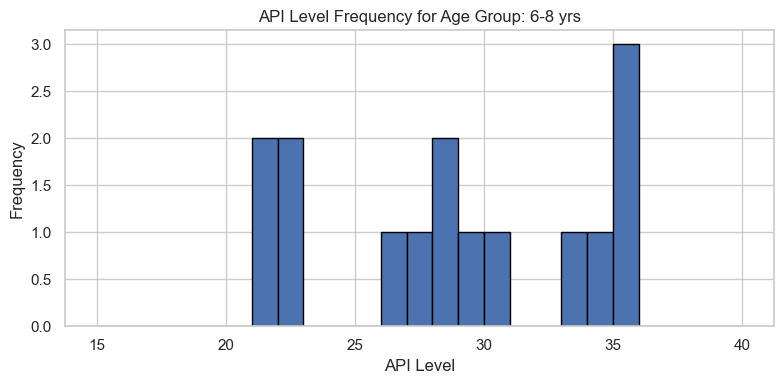

C:\Users\Admin\AppData\Local\Temp\ipykernel_11588\4087376081.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group_df['api_level'] = group_df['api_level'].astype(int)


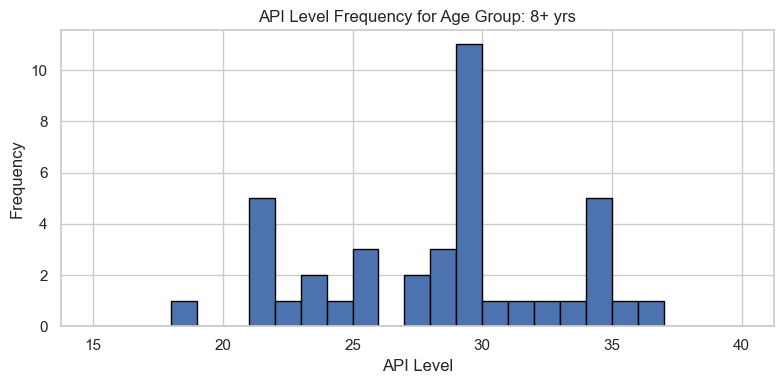

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# === CONFIG ===
# Adjust paths if needed
REPO_METRICS_CSV = r"F:\Android_Mobile_App\AndroidProject_3rd\6.2-Shallow_Clone\Analysis Output\7.4-Total_Repos_WithMetrics.csv"
API_DETAILS_CSV = r"F:\Android_Mobile_App\AndroidProject_3rd\6.2-Shallow_Clone\Analysis Output\7.2-Project_List_API_Details_3rdAttempt_ShallowC.csv"

# === Load CSV files ===
repo_metrics = pd.read_csv(REPO_METRICS_CSV)
api_details = pd.read_csv(API_DETAILS_CSV)

# === Merge to attach 'age_group' to each API level ===
merged_df = pd.merge(
    api_details,
    repo_metrics[['full_name', 'age_group']],
    on='full_name',
    how='left'
)

# === Plot: Histogram for each age group ===
# Get unique age groups (drop NaN)
age_groups = merged_df['age_group'].dropna().unique()

# Loop over each age group and plot histogram
for age_group in sorted(age_groups):
    group_df = merged_df[merged_df['age_group'] == age_group]
    plt.figure(figsize=(8, 4))
    # Ensure API levels are integers
    group_df['api_level'] = group_df['api_level'].astype(int)
    # Plot histogram with bin range covering typical Android API levels
    group_df['api_level'].hist(
        bins=range(15, 41),
        edgecolor='black'
    )
    plt.title(f"API Level Frequency for Age Group: {age_group}")
    plt.xlabel("API Level")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


C:\Users\Admin\AppData\Local\Temp\ipykernel_11588\656365394.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group_df['api_level'] = group_df['api_level'].astype(int)


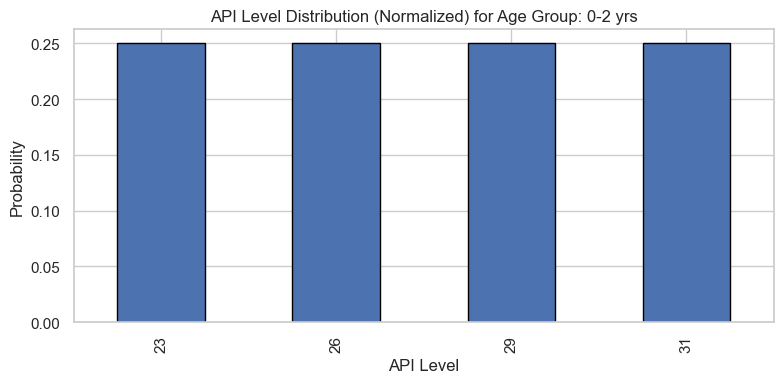

C:\Users\Admin\AppData\Local\Temp\ipykernel_11588\656365394.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group_df['api_level'] = group_df['api_level'].astype(int)


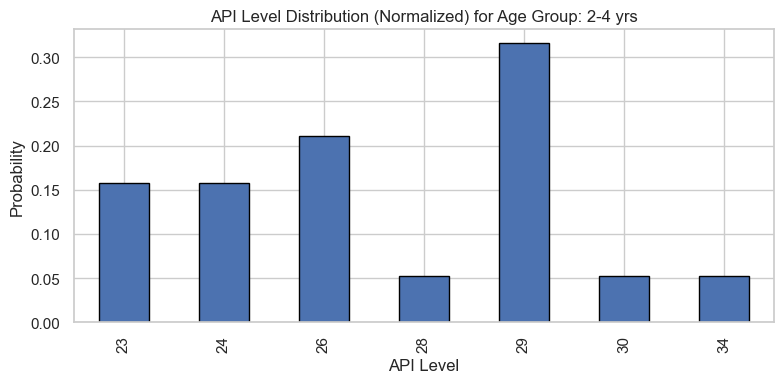

C:\Users\Admin\AppData\Local\Temp\ipykernel_11588\656365394.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group_df['api_level'] = group_df['api_level'].astype(int)


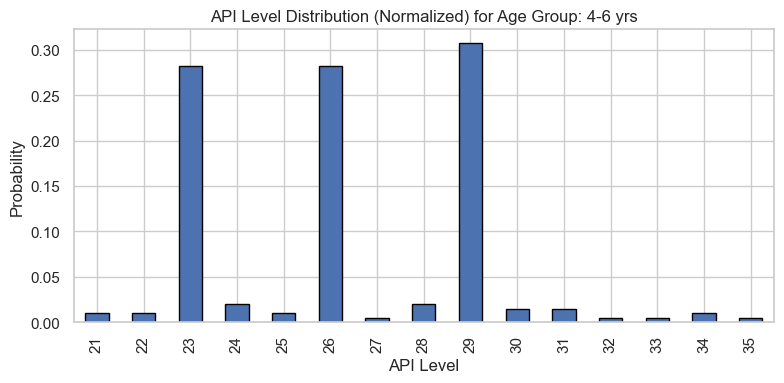

C:\Users\Admin\AppData\Local\Temp\ipykernel_11588\656365394.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group_df['api_level'] = group_df['api_level'].astype(int)


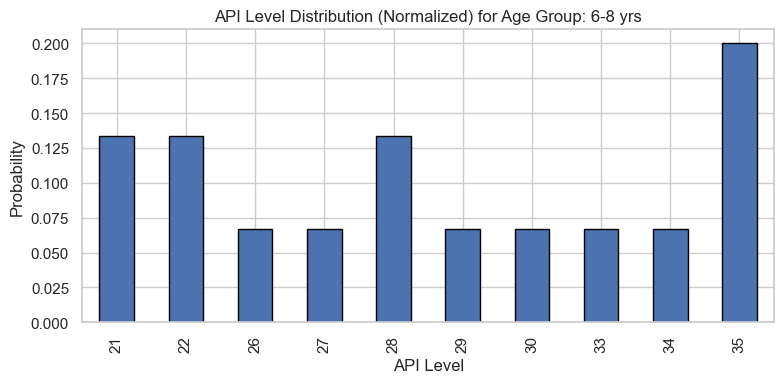

C:\Users\Admin\AppData\Local\Temp\ipykernel_11588\656365394.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group_df['api_level'] = group_df['api_level'].astype(int)


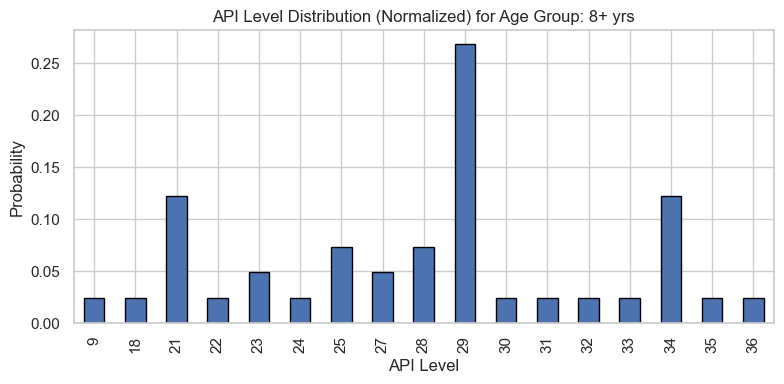

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# === CONFIG ===
REPO_METRICS_CSV = r"F:\Android_Mobile_App\AndroidProject_3rd\6.2-Shallow_Clone\Analysis Output\7.4-Total_Repos_WithMetrics.csv"
API_DETAILS_CSV = r"F:\Android_Mobile_App\AndroidProject_3rd\6.2-Shallow_Clone\Analysis Output\7.2-Project_List_API_Details_3rdAttempt_ShallowC.csv"

# === Load CSV files ===
repo_metrics = pd.read_csv(REPO_METRICS_CSV)
api_details = pd.read_csv(API_DETAILS_CSV)

# === Merge ===
merged_df = pd.merge(
    api_details,
    repo_metrics[['full_name', 'age_group']],
    on='full_name',
    how='left'
)

# === Plot: API level distribution (normalized) for each age group ===
age_groups = merged_df['age_group'].dropna().unique()

for age_group in sorted(age_groups):
    group_df = merged_df[merged_df['age_group'] == age_group]
    group_df['api_level'] = group_df['api_level'].astype(int)

    # Count occurrences
    counts = group_df['api_level'].value_counts().sort_index()
    total = counts.sum()

    # Normalize to get distribution
    probs = counts / total

    # Plot
    plt.figure(figsize=(8, 4))
    probs.plot(kind='bar', edgecolor='black')
    plt.title(f"API Level Distribution (Normalized) for Age Group: {age_group}")
    plt.xlabel("API Level")
    plt.ylabel("Probability")
    plt.grid(True, axis='y')
    plt.tight_layout()
    plt.show()
